# Image Classification Using Convolutional Neural Network (CNN)

In [105]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

## Load the dataset 
We use cifar10 dataset from tensorflow keras datasets

In [106]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()
X_train.shape

(50000, 32, 32, 3)

In [107]:
X_test.shape

(10000, 32, 32, 3)

In [108]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [109]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [110]:
def plot_sample(X, y, index):
    plt.figure(figsize=(15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

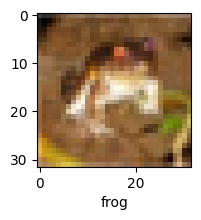

In [111]:
plot_sample(X_train, y_train, 0)

## Normalizing the training data

In [112]:
X_train = X_train / 255.0
X_test = X_test / 255.0

## Build simple artificial neural network for image classification
This will be used as a baseline.

In [113]:
ann = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Flatten(),
    layers.Dense(3000, activation='relu'),
    layers.Dense(1000, activation='relu'),
    layers.Dense(10, activation='sigmoid')
])

ann.compile(optimizer='SGD',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

ann.fit(X_train, y_train, epochs=5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 47s 30ms/step - accuracy: 0.3536 - loss: 1.8125
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 97s 62ms/step - accuracy: 0.4264 - loss: 1.6255
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 146s 65ms/step - accuracy: 0.4580 - loss: 1.5408
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 135s 60ms/step - accuracy: 0.4780 - loss: 1.4807
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 95s 61ms/step - accuracy: 0.4952 - loss: 1.4326


In [114]:
ann.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.4654 - loss: 1.4958


[1.4958150386810303, 0.46540001034736633]

In [115]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report:\n", classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.37      0.48      1000
           1       0.68      0.48      0.56      1000
           2       0.57      0.10      0.18      1000
           3       0.32      0.30      0.31      1000
           4       0.51      0.30      0.38      1000
           5       0.31      0.53      0.39      1000
           6       0.44      0.70      0.54      1000
           7       0.54      0.55      0.54      1000
           8       0.44      0.80      0.57      1000
           9       0.59      0.52      0.55      1000

    accuracy                           0.47     10000
   macro avg       0.51      0.47      0.45     10000
weighted avg       0.51      0.47      0.45     10000



## Now let us build a convolutional neural network to train our images

In [116]:
cnn = models.Sequential([
    # CNN
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2,2)),

    # Dense
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

c:\Users\kflmo\Documents\Projects\ML\03-ImageClassification\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [117]:
cnn.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])


In [118]:
cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1386s 885ms/step - accuracy: 0.4642 - loss: 1.4850
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.5939 - loss: 1.1502
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.6394 - loss: 1.0286
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.6703 - loss: 0.9478
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.6883 - loss: 0.8920
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.7071 - loss: 0.8426
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.7233 - loss: 0.7971
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.7373 - loss: 0.7585
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 16ms/step - accuracy: 0.7484 - loss: 0.7245
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.7533 - loss: 0.7051


In [119]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6801 - loss: 0.9527


[0.9526691436767578, 0.6801000237464905]

In [120]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[3, 8, 8, 8, 4]

In [121]:
y_test = y_test.reshape(-1,)
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

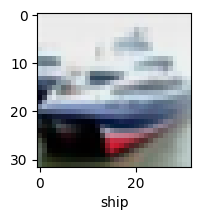

In [122]:
plot_sample(X_test, y_test, 1)

In [123]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


array([[1.0216093e-04, 1.2531309e-05, 3.9750713e-04, 9.4454330e-01,
        5.1738782e-04, 3.3322252e-02, 2.1356479e-03, 2.6843185e-05,
        1.8614594e-02, 3.2781067e-04],
       [2.2749042e-03, 4.5320573e-03, 3.0097041e-08, 2.5075510e-08,
        1.2939860e-08, 1.8206982e-10, 1.1975333e-09, 2.2798026e-10,
        9.9298191e-01, 2.1111972e-04],
       [5.4938808e-02, 8.3055925e-03, 3.4519206e-04, 9.3245687e-04,
        1.4636356e-04, 2.3448636e-04, 1.7698636e-05, 3.6644068e-04,
        8.9103252e-01, 4.3680515e-02],
       [5.4748487e-01, 1.1363270e-04, 3.7207613e-03, 1.0228637e-04,
        7.3935408e-03, 1.1142024e-05, 2.4818538e-03, 2.7757847e-06,
        4.3867764e-01, 1.1489321e-05],
       [6.4542428e-07, 6.3785148e-05, 2.3626516e-02, 2.4258148e-02,
        1.5122759e-01, 6.4308959e-04, 7.9868728e-01, 1.3758584e-07,
        1.4911683e-03, 1.6670296e-06]], dtype=float32)

In [124]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[3, 8, 8, 0, 6]

In [125]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

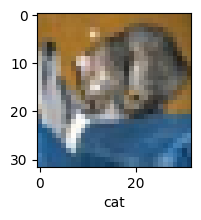

In [126]:
plot_sample(X_test, y_test, 0)

In [127]:
classes[y_classes[0]]

'cat'

In [128]:
print("Classification Report:\n", classification_report(y_test, y_classes))

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.64      0.70      1000
           1       0.85      0.77      0.81      1000
           2       0.61      0.51      0.55      1000
           3       0.47      0.55      0.51      1000
           4       0.55      0.69      0.61      1000
           5       0.65      0.54      0.59      1000
           6       0.78      0.73      0.75      1000
           7       0.73      0.76      0.74      1000
           8       0.70      0.86      0.77      1000
           9       0.79      0.75      0.77      1000

    accuracy                           0.68     10000
   macro avg       0.69      0.68      0.68     10000
weighted avg       0.69      0.68      0.68     10000

